# Jacobson-Galán 2024 bolometric light curves with Gopreaux

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from caat import CAAT, SNCollection, GP3D, Kernel, SNModel, SN
from sklearn.gaussian_process.kernels import RBF
from astropy import units as u
import pickle as pkl
import logging
logging.getLogger().setLevel(logging.ERROR)
from caat.utils import WLE
mpl.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

In [2]:
colors= ['#e51f00', '#ffaa00', '#59b359', '#00c2f2', '#502db3', '#f2b6de']

In [3]:
metadata = pd.read_csv('./data/Jacobson-Galan_typeII_SNe.csv')

In [4]:
metadata.head()

,SN name,Paper,L_bol Available,Bands,Host Galaxy Corrected,Type,Subtype,Distance_mpc,Distance_err_mpc,ebv_host,ebv_host_err
0,SN2013fs,"Jacobson-Galán et al. 2024, ApJ, Final Moments II",True,UV/OPT/NIR,True,SNII,SNIIP,50.6,0.9,0.02,0.004
1,SN2016blz,"Jacobson-Galán et al. 2024, ApJ, Final Moments II",True,UV/OPT/NIR,True,SNII,SNII,51.4,3.6,0.12,0.024
2,SN2018dfc,"Jacobson-Galán et al. 2024, ApJ, Final Moments II",True,UV/OPT/NIR,True,SNII,SNII,153.5,10.7,0.14,0.030
3,SN2018fif,"Jacobson-Galán et al. 2024, ApJ, Final Moments II",True,UV/OPT/NIR,True,SNII,SNII,73.8,5.2,0.18,0.040
4,SN2018zd,"Jacobson-Galán et al. 2024, ApJ, Final Moments II",True,UV/OPT/NIR,True,SNII,SNII,18.4,4.5,0.17,0.030


## Loading the IIP SNe collection

In [5]:
ii = SNCollection(sntype="SNII", snsubtype="SNII")
norm_set = SNCollection(sntype="SNII")

print("Type II SNe in collection: %i"%len(ii.sne))

Type II SNe in collection: 238


## Fitting the 2D GP surface

In [59]:
kernel = Kernel(RBF([np.log(10.0), np.log10(500.0)], (0.1, 4.0)))

filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i']
phasemin    = -20
phasemax    =  100   
log_transform = 30   # log-space offset
mangle_sed  = True   # Using shifted wavelengths for better SED prediction

gp = GP3D(
    ii,
    kernel,
    filts,
    phasemin,
    phasemax,
    set_to_normalize=norm_set,
    log_transform=log_transform,
    mangle_sed=mangle_sed,
)

### Optimising kernel hyperparameters


In [60]:
kernel_params = gp.optimize_hyperparams(subtract_polynomial=True)

optimized = np.asarray(
    [np.median([k[i] for k in kernel_params])
     for i in range(len(kernel_params[0]))]
)
print("Optimised kernel hyperparameters:", np.exp(optimized))

Optimised kernel hyperparameters: [2.88035418 2.57455764]


### Fit all SN and build the template surface

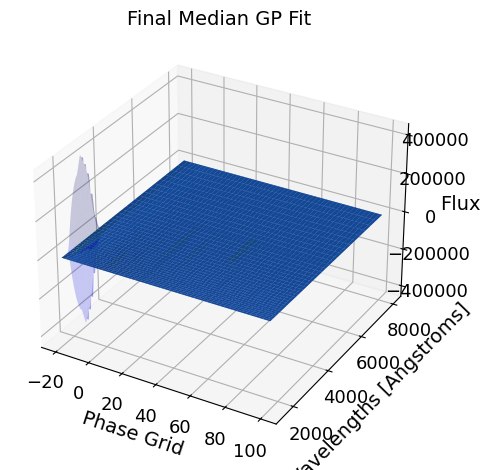

In [61]:
snmodel = gp.predict(
    plot=False,
    subtract_polynomial=True,
    fit_separately=True,
    
)

## Reading a saved GP model for SNe type Ib


In [5]:
snmodel = SNModel(
    surface="SNII_SNII_GP_model.fits",
)

## Reading saved bolometric light curves from Jacobson-Galan et al. 2024

In [6]:
BOL_PICKLE_FILE = './data/SNeII_bolometric_lcs_with_metadata_Jacobson-Galan.pkl'
with open(BOL_PICKLE_FILE, 'rb') as f:
    bol_pkg = pkl.load(f)

In [7]:
def plot_bol_lc (phases, L_bol, L_bol_up, L_bol_low, phase_lit, L_lit, L_lit_err):

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(phases, L_bol, color=colors[0], lw=2.5,
            label='GP bolometric')
    ax.fill_between(phases,
                    L_bol_up,
                    L_bol_low,
                    alpha=0.25, color=colors[0], label=r'1$\sigma$')
    ax.errorbar(phase_lit, L_lit,  
                yerr=L_lit_err, 
                fmt='o', color='grey', alpha=0.8, zorder=3,markersize=5,
                elinewidth=1.4, capsize=3, capthick=1.4, rasterized=True,label='Literature Bol')

    ax.set_xlabel('Phase (days since explosion)')
    ax.set_ylabel(r"$L_{\rm Bol}$ (erg s$^{-1}$)")
    ax.set_title('Type Ib Bolometric Light Curve for SN2008D')
    ax.legend(fontsize=11)
    plt.tight_layout()
#     ax.set_ylim(1e38, 1e4)
    ax.set_yscale('log')
    # ax.set_xlim(0.7
    #             , 40)
    # ax.set_xscale('log')
    plt.show()

## Reading in data for a each SN in the sample

0it [00:00, ?it/s]

Reading bolometric lc of SN2018dfc from Jacobson-Galán 2024.
Reading SN data from CAAT and fixing for host galaxy extinction
Fitting SN data with Gopreaux


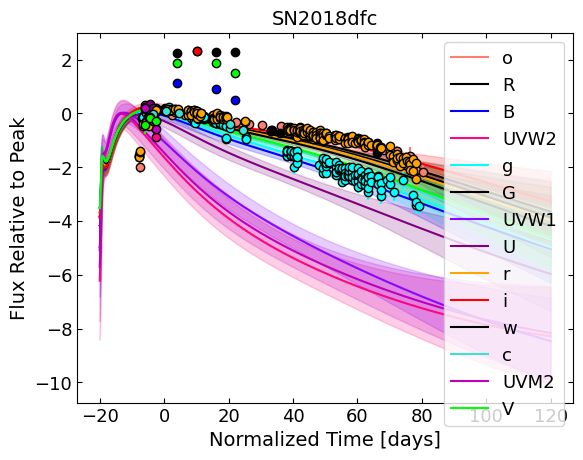

Predicting SED per phase grid using Gopreaux.



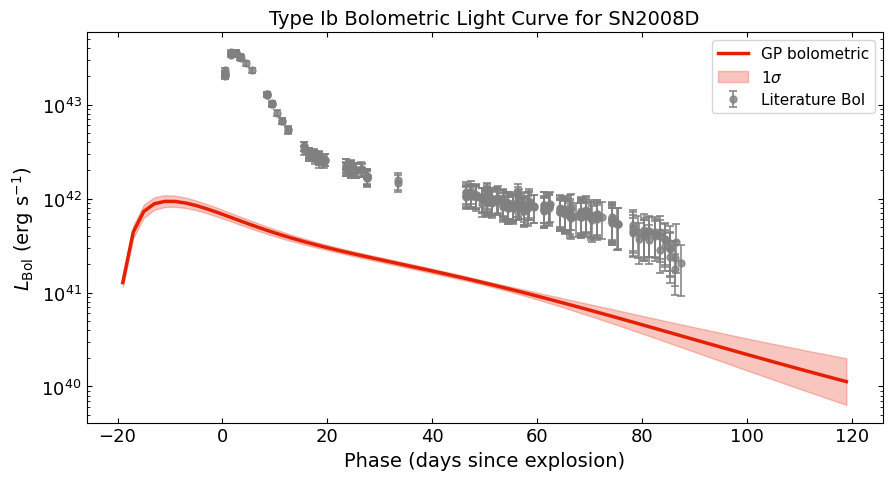

1it [00:03,  3.26s/it]


In [18]:
from caat import DataCube
from tqdm import tqdm

bol_lc_all = {}


for i, snname in tqdm(enumerate([metadata['SN name'].values[2]])):
    sn = SN(name=snname)
    
    snmodel = SNModel(
    surface="SNII_SNII_GP_model.fits",
    )
    if metadata['Subtype'][metadata['SN name']==snname].values[0] != 'SNII':
        continue
    print('Reading bolometric lc of %s from Jacobson-Galán 2024.'%snname)
    bol_lc_lit_ph = bol_pkg['lightcurves'][snname]['data']['phase_days'].values
    bol_lc_lit_l = bol_pkg['lightcurves'][snname]['data']['bol_lum_erg_s'].values
    bol_lc_lit_l_err = bol_pkg['lightcurves'][snname]['data']['bol_lum_err_erg_s'].values
    
    print('Reading SN data from CAAT and fixing for host galaxy extinction')
#     try:
#         a_v = float(metadata['ebv_host'].values[i])*3.1
#         cube = DataCube(sn=sn, a_v=a_v)
#         cube.measure_flux_in_filter(overwrite=True, save=True)
#     except:
#         print('SN %s has no valid a_v.'%snname)
#         continue
    print ('Fitting SN data with Gopreaux')
    snmodel.fit_photometry(
    sn_to_fit=sn, 
    show=True,
    nsamples=1,
    keep_new_fit=True)
    
    # reference-band
    zp_peak    = sn.zps[sn.info["peak_filt"]]
    f_peak_ref = zp_peak * 1e-11 * 10 ** (-0.4 * sn.info["peak_mag"])
    f_peak_ref_log = np.log10(f_peak_ref)

    # phase grid
    phase_min, phase_max, phase_step = snmodel.min_phase+1, snmodel.max_phase-1, 2 
    phases = np.arange(phase_min, phase_max + phase_step, phase_step)

    F_bol   = np.zeros(len(phases))
    F_up = np.zeros(len(phases))
    F_low = np.zeros(len(phases))

    print ('Predicting SED per phase grid using Gopreaux.')
    for ph, phase in enumerate(phases):
        x, shifted_flux, sigma = snmodel.predict_sed(
            wavelength_min=snmodel.min_wl+1,
            wavelength_max=snmodel.max_wl-1,
            phase=phase,
            show=False
        )

        f_lambda       = 10 ** (shifted_flux + f_peak_ref_log) #* 10e15
        f_lambda_upper = 10 ** (shifted_flux + f_peak_ref_log + sigma) #* 10e15
        f_lambda_lower = 10 ** (shifted_flux + f_peak_ref_log - sigma) #* 10e15

        F_bol[ph]   = np.trapezoid(f_lambda, x)
        F_up[ph]   = np.trapezoid(f_lambda_upper, x)
        F_low[ph]   = np.trapezoid(f_lambda_lower, x)

    try:
        d_L = metadata['Distance_mpc'].values[i] * u.Mpc.to(u.cm)
    except:
        print('SN %s has no valid distance.'%snname)
        continue
    print()
    L_bol = 4 * np.pi * d_L**2 * F_bol
    L_bol_up = 4 * np.pi * d_L**2 * F_up
    L_bol_low = 4 * np.pi * d_L**2 * F_low
    
    bol_lc_all[snname] = {}
    bol_lc_all[snname]['L_bol'] = L_bol
    bol_lc_all[snname]['L_bol_upper'] = L_bol_up
    bol_lc_all[snname]['L_bol_lower'] = L_bol_low
    
    plot_bol_lc (phases, L_bol, L_bol_up, L_bol_low, bol_lc_lit_ph, bol_lc_lit_l, bol_lc_lit_l_err)
